<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/hw_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2
Homework for the module "Learning Algorithms with a Teacher Part 2"

## Part 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import TargetEncoder, StandardScaler, LabelEncoder, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer

from google.colab import files

In [ ]:
!kaggle datasets download -d jsphyg/weather-dataset-rattle-package
!unzip weather-dataset-rattle-package.zip

Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
License(s): other
weather-dataset-rattle-package.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  weather-dataset-rattle-package.zip
replace weatherAUS.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: weatherAUS.csv          


## Part 2

In [ ]:
data = pd.read_csv("weatherAUS.csv")
data.head()
# data.shape
# data.info()
# data.describe()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## Part 3

We are doing the same action as we have on the lecture to prepare the dataset.

### Part 3.1

In [ ]:
data.isna().mean().sort_values(ascending=False)
data = data[data.columns[data.isna().mean().lt(0.35)]]
data = data.dropna(subset='RainTomorrow')

### Part 3.2

In [ ]:
data_num = data.select_dtypes(include=np.number)
data_cat = data.select_dtypes(include='object')

### Part 3.3

In [ ]:
data_cat["Date"] = pd.to_datetime(data["Date"])
data_cat["Year"] = data_cat["Date"].dt.year
data_cat["Month"] = data_cat["Date"].dt.month

In [ ]:
data_cat.drop(columns=["Date"], inplace=True)
data_cat["Month"] = data_cat["Month"].astype(str)

### Part 3.4

In [ ]:
data_num["Year"] = data_cat["Year"]

data_cat.drop(columns=["Year"], inplace=True)

### Part 3.5

In [ ]:
last_year = data_num["Year"].max()

In [ ]:
test_mask = data_num["Year"] == last_year
print(test_mask.value_counts())

Year
False    133727
True       8466
Name: count, dtype: int64


In [ ]:
# Split numerical features
X_train_num = data_num[~test_mask]
X_test_num = data_num[test_mask]

# Split categorical features (without target)
X_train_cat = data_cat.drop(columns=["RainTomorrow"])[~test_mask]
X_test_cat = data_cat.drop(columns=["RainTomorrow"])[test_mask]

# Split target
y_train = data["RainTomorrow"][~test_mask]
y_test = data["RainTomorrow"][test_mask]

In [ ]:
print("Train numeric:", X_train_num.shape)
print("Test numeric :", X_test_num.shape)

print("Train categorical:", X_train_cat.shape)
print("Test categorical :", X_test_cat.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain years:", sorted(X_train_num["Year"].unique()))
print("Test years:", sorted(X_test_num["Year"].unique()))

Train numeric: (133727, 13)
Test numeric : (8466, 13)
Train categorical: (133727, 6)
Test categorical : (8466, 6)
y_train: (133727,)
y_test : (8466,)

Train years: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016)]
Test years: [np.int32(2017)]


## Part 4

In [ ]:
num_imputer = SimpleImputer().set_output(transform="pandas")

X_train_num = num_imputer.fit_transform(X_train_num)
X_test_num = num_imputer.transform(X_test_num)

pd.concat([X_train_num, X_test_num]).isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0
Pressure9am,0
Pressure3pm,0


In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')

X_train_cat = cat_imputer.fit_transform(X_train_cat)
X_test_cat = cat_imputer.transform(X_test_cat)

pd.concat([X_train_cat, X_test_cat]).isna().sum()

,0
Location,0
WindGustDir,0
WindDir9am,0
WindDir3pm,0
RainToday,0
Month,0


## Part 5

In [ ]:
scaler = StandardScaler().set_output(transform='pandas')

X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)

## Part 6

In [ ]:
encoder = (OneHotEncoder(drop='if_binary', sparse_output=False).set_output(transform='pandas'))

X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

X_train_cat.shape

(133727, 110)

In [ ]:
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

X_train.shape

(133727, 123)

## Part 7

In [ ]:
y_train.value_counts(normalize=True)

,proportion
RainTomorrow,
No,0.77481
Yes,0.22519


In [ ]:
clf = (LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42).fit(X_train, y_train))

pred = clf.predict(X_test)

## Part 8

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



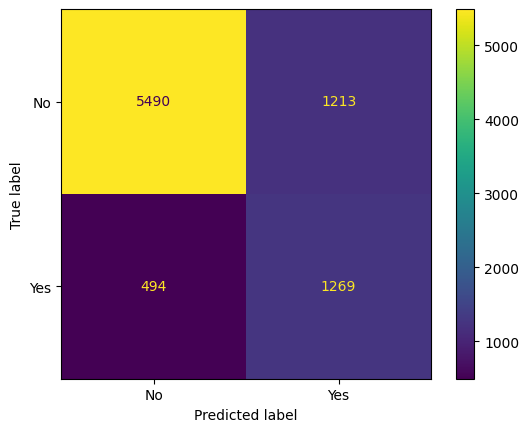

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()

## Summary

After preprocessing the data, filling in missing values, coding categorical features, and training the logistic regression model, Accuracy = 0.80 was obtained, indicating the correct classification of about 80% of the observations. The model predicts the absence of rain well (Precision = 0.92, F1-score = 0.87 for the No class) and successfully detects most rainy days (Recall = 0.72 for the Yes class). At the same time, Precision for the Yes class is 0.51, since the model quite often predicts rain incorrectly (1213 false positive cases). This is a consequence of using the class_weight="balanced" parameter, which improves the detection of the underrepresented class at the cost of increasing the number of false positives. Overall, the model demonstrates good classification quality and is suitable for basic precipitation forecasting.